## Speech Emotion Recognition: Chargement et Extraction de features
### Étapes :
1. **Imports & Session Spark**
2. **Chargement des fichiers audio**
3. **Extraction des labels** depuis les noms de fichiers
4. **Split** (80/20) + **Micro-Partitionnement**
5. **Data Augmentation** (Train uniquement) — Pitch Shift, Bruit Blanc, Time Stretch
6. **Extraction de features multi-échelle** (185 dimensions)
7. **Sauvegarde en Parquet**
8. **Vérification audio** (écoute original vs augmenté)

---
### Imports & Session Spark

In [ ]:
import os
import io
import librosa

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    udf, col, lit
)
from pyspark.sql.types import (
    BinaryType, ArrayType, FloatType, StringType
)

# --- Création de la session Spark ---
# Mémoire augmentée pour supporter l'audio binaire
# Arrow activé pour les transferts JVM - Python rapides
spark = (
    SparkSession.builder
    .appName("SER_Pipeline")
    .master("local[4]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.memory.offHeap.enabled", "true")
    .config("spark.memory.offHeap.size", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.maxResultSize", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Session Spark démarrée :", spark.version)

Session Spark démarrée : 4.1.1


---
### Chargement des fichiers audio

In [3]:
DATASET_PATH = "Dataset/"

# Chargement de tous les fichiers .wav en binaire
# binaryFile lit le contenu brut de chaque fichier dans la colonne "content"
df_raw = (
    spark.read.format("binaryFile")
    .option("pathGlobFilter", "*.wav")
    .option("recursiveFileLookup", "true")
    .load(DATASET_PATH)
    .select(
        col("path"),
        col("content")
    )
)

print(f"Nombre total de fichiers audio chargés : {df_raw.count()}")
df_raw.printSchema()

Nombre total de fichiers audio chargés : 12162
root
 |-- path: string (nullable = true)
 |-- content: binary (nullable = true)



---
### Extraction des Labels depuis les noms de fichiers

Datasets supportés :
- **RAVDESS** : `03-01-05-01-02-01-24.wav` → 3ème segment = émotion
- **CREMA-D** : `1001_DFA_ANG_XX.wav` → 3ème segment = code émotion
- **TESS** : `OAF_back_angry.wav` → dernier segment = émotion
- **SAVEE** : `DC_a01.wav` → lettres dans le 2ème segment = émotion

In [4]:
from pyspark.sql import functions as F

# On commence d'abord par identifier les différents datasets
df_labeled = df_raw.withColumn("dataset",
    F.when(F.col("path").contains("Ravdess"), "RAVDESS")
     .when(F.col("path").contains("Crema"), "CREMA")
     .when(F.col("path").contains("Tess"), "TESS")
     .when(F.col("path").contains("Savee"), "SAVEE")
)

# On extrait ensuite les labels à partir des chemins de fichiers par regexp
df_labeled = df_labeled.withColumn("label",
    F.when(F.col("dataset") == "RAVDESS", F.regexp_extract("path", r"(\d{2})-(\d{2})-(\d{2})-", 3)) # XX-XX-XX-, 3ème groupe (ex: 03-01-01- -> 01)
     .when(F.col("dataset") == "CREMA", F.regexp_extract("path", r"_([A-Z]{3})_([A-Z]+)\.wav", 1))  # ABC_XX.wav, 1er groupe (ex: _ANG_XX.wav -> ANG)
     .when(F.col("dataset") == "TESS", F.regexp_extract("path", r"_([a-z]+)\.wav", 1)) # Dernier mot avant .wav (ex: _angry.wav -> angry)
     .when(F.col("dataset") == "SAVEE", F.regexp_extract("path", r"([a-z]+)\d{2}\.wav", 1)) # La/les lettre(s) avant les chiffres (ex: a01.wav -> a)
)

# Mapping des labels pour uniformisation entre les datasets
mapping = {
    "happy": ["03", "HAP", "happy", "h"],
    "sad": ["04", "SAD", "sad", "sa"],
    "angry": ["05", "ANG", "angry", "a"],
    "fear": ["06", "FEA", "fear", "f"],
    "disgust": ["07", "DIS", "disgust", "d"],
    "surprise": ["08", "ps", "su", "surprise"],
    "neutral": ["01", "02", "NEU", "neutral", "n"] # "02" (calm) est fusionné ici
}

df_labeled = df_labeled.withColumn("label",
    F.when(F.col("label").isin(mapping["happy"]), "happy")
     .when(F.col("label").isin(mapping["sad"]), "sad")
     .when(F.col("label").isin(mapping["angry"]), "angry")
     .when(F.col("label").isin(mapping["fear"]), "fear")
     .when(F.col("label").isin(mapping["disgust"]), "disgust")
     .when(F.col("label").isin(mapping["surprise"]), "surprise")
     .when(F.col("label").isin(mapping["neutral"]), "neutral")
     .otherwise("unknown")
).filter(F.col("label") != "unknown") # On dégage les erreurs direct

df_labeled.groupBy("label").count().orderBy("count", ascending=False).show()

+--------+-----+
|   label|count|
+--------+-----+
|   angry| 1923|
|     sad| 1923|
|    fear| 1923|
|   happy| 1923|
| disgust| 1923|
| neutral| 1895|
|surprise|  652|
+--------+-----+



##### Class Distribution

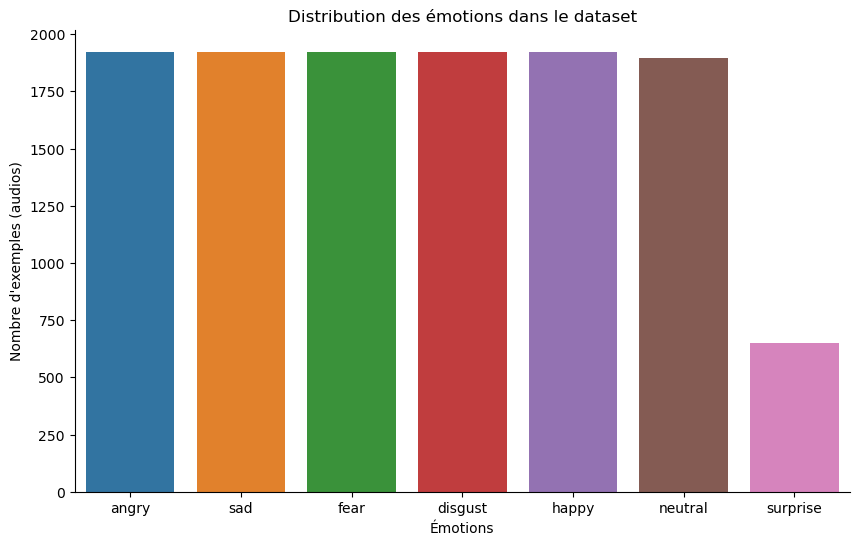

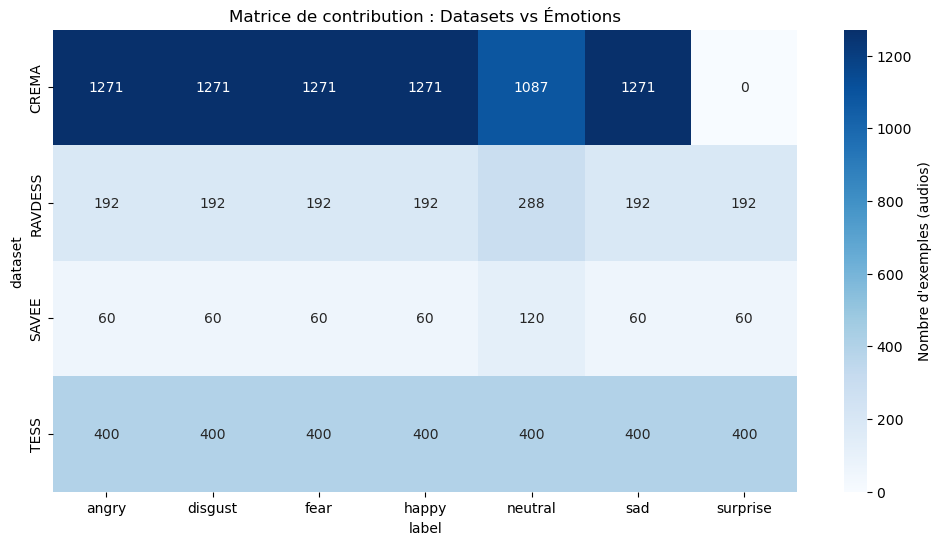

In [18]:
# Convertir le DataFrame Spark en Pandas pour la visualisation
pdf_counts = df_labeled.groupBy("label").count().toPandas()

# Visualiser la distribution des émotions
plt.figure(figsize=(10, 6))
sns.barplot(x="label", y="count", data=pdf_counts.sort_values("count", ascending=False), hue="label", palette="tab10")
sns.despine()
plt.title("Distribution des émotions dans le dataset")
plt.xlabel("Émotions")
plt.ylabel("Nombre d'exemples (audios)")
plt.show()

# Groupement par dataset et label
pdf_distribution = df_labeled.groupBy("dataset", "label").count().toPandas()

# Pivot pour avoir les datasets en lignes et labels en colonnes
heatmap_data = pdf_distribution.pivot(index="dataset", columns="label", values="count").fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': 'Nombre d\'exemples (audios)'})

plt.title("Matrice de contribution : Datasets vs Émotions")
plt.show()

---
### Split (80/20) + Micro-Partitionnement

In [ ]:
# Split
df_train, df_test = df_labeled.randomSplit([0.8, 0.2], seed=42)

# Saubegarde des chemins des fichiers test et train
df_test.select("path", "label").toPandas().to_csv(DATASET_PATH + "liste_fichiers_test.csv", index=False)
df_train.select("path", "label").toPandas().to_csv(DATASET_PATH + "liste_fichiers_train.csv", index=False)

# --- Micro-Partitionnement ---
# Repartitionner le train en 200 partitions pour réduire le volume
# de données binaires chargées par tâche Spark (anti-OOM)
df_train = df_train.repartition(200)

train_count = df_train.count()
test_count = df_test.count()
print(f"Split anti-leakage + micro-partitionnement :")
print(f"   Train : {train_count} échantillons (repartitionné en 200 partitions)")
print(f"   Test  : {test_count} échantillons")

# --- Vérification : aucun fichier en commun ---
train_paths = set(df_train.select("path").rdd.flatMap(lambda x: x).collect())
test_paths = set(df_test.select("path").rdd.flatMap(lambda x: x).collect())
overlap = train_paths & test_paths
assert len(overlap) == 0, f"FUITE DE DONNÉES : {len(overlap)} fichiers dans les deux sets !"
print("Aucune fuite de données, train et test sont disjoints.")

Split anti-leakage + micro-partitionnement :
   Train : 9680 échantillons (repartitionné en 200 partitions)
   Test  : 2482 échantillons


Aucune fuite de données, train et test sont disjoints.


---
### Data Augmentation (Train uniquement)

In [6]:
@udf(returnType=BinaryType())
def pitch_shift_udf(audio_bytes):
    """Pitch shifting (+4 demi-tons).
    Entrée : bytes WAV bruts  →  Sortie : bytes WAV transformés."""
    import io, librosa, numpy as np, soundfile as sf
    try:
        # Décodage du binaire WAV en signal numpy
        y, sr = librosa.load(io.BytesIO(audio_bytes), sr=22050)
        # Décalage de 4 demi-tons vers le haut
        y_shifted = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=4)
        # Ré-encodage en binaire WAV
        buffer = io.BytesIO()
        sf.write(buffer, y_shifted, sr, format="WAV")
        return buffer.getvalue()
    except Exception:
        return audio_bytes  # Fallback : retourner l'original

@udf(returnType=BinaryType())
def add_noise_udf(audio_bytes):
    """Ajout de bruit blanc gaussien (facteur 0.005).
    Entrée : bytes WAV bruts  →  Sortie : bytes WAV bruités."""
    import io, librosa, numpy as np, soundfile as sf
    try:
        y, sr = librosa.load(io.BytesIO(audio_bytes), sr=22050)
        # Génération du bruit blanc
        noise = np.random.randn(len(y)) * 0.005
        y_noisy = y + noise.astype(np.float32)
        buffer = io.BytesIO()
        sf.write(buffer, y_noisy, sr, format="WAV")
        return buffer.getvalue()
    except Exception:
        return audio_bytes

@udf(returnType=BinaryType())
def time_stretch_udf(audio_bytes):
    """Time stretching (facteur 1.2 = 20% plus rapide).
    Entrée : bytes WAV bruts  →  Sortie : bytes WAV étirés."""
    import io, librosa, numpy as np, soundfile as sf
    try:
        y, sr = librosa.load(io.BytesIO(audio_bytes), sr=22050)
        # Accélération de 20% sans changer le pitch
        y_stretched = librosa.effects.time_stretch(y=y, rate=1.2)
        buffer = io.BytesIO()
        sf.write(buffer, y_stretched, sr, format="WAV")
        return buffer.getvalue()
    except Exception:
        return audio_bytes

In [7]:
# =================================================================
# Sauvegarde Itérative
# -----------------------------------------------------------------
# On écrit chaque version séquentiellement en Parquet :
#   1. original    -> mode overwrite  (crée le fichier)
#   2. pitch_shift -> mode append
#   3. white_noise -> mode append
#   4. time_stretch -> mode append
# Avec clearCache() entre chaque étape pour libérer le Heap JVM.
# =================================================================

AUGMENTED_PARQUET = DATASET_PATH + "augmented/augmented_train.parquet"

# Schéma commun : path, content, label, augmentation

# --- 1/4 : Originaux (overwrite = crée le Parquet) ---
print("[1/4] Écriture des originaux (overwrite)...")
df_train_original = df_train.withColumn("augmentation", lit("original"))
df_train_original.write.mode("overwrite").parquet(AUGMENTED_PARQUET)
print(f"Originaux sauvegardés ({train_count} fichiers)")

# Libération mémoire JVM
# df_train_original.unpersist()
del df_train_original
spark.catalog.clearCache()

# --- 2/4 : Pitch Shift (append) ---
print("[2/4] Augmentation Pitch Shift (append)...")
df_aug_pitch = (
    df_train
    .withColumn("content", pitch_shift_udf(col("content")))
    .withColumn("augmentation", lit("pitch_shift"))
)
df_aug_pitch.write.mode("append").parquet(AUGMENTED_PARQUET)
print("Pitch Shift sauvegardé")

# Libération mémoire JVM
del df_aug_pitch
spark.catalog.clearCache()

# --- 3/4 : Bruit Blanc (append) ---
print("[3/4] Augmentation Bruit Blanc (append)...")
df_aug_noise = (
    df_train
    .withColumn("content", add_noise_udf(col("content")))
    .withColumn("augmentation", lit("white_noise"))
)
df_aug_noise.write.mode("append").parquet(AUGMENTED_PARQUET)
print("Bruit Blanc sauvegardé")

del df_aug_noise
spark.catalog.clearCache()

# --- 4/4 : Time Stretch (append) ---
print("[4/4] Augmentation Time Stretch (append)...")
df_aug_stretch = (
    df_train
    .withColumn("content", time_stretch_udf(col("content")))
    .withColumn("augmentation", lit("time_stretch"))
)
df_aug_stretch.write.mode("append").parquet(AUGMENTED_PARQUET)
print("Time Stretch sauvegardé")

# Libération mémoire JVM finale
del df_aug_stretch
spark.catalog.clearCache()

# --- Relecture depuis le disque ---
print("\nRelecture du Parquet consolidé...")
df_train_augmented = spark.read.parquet(AUGMENTED_PARQUET)

augmented_count = df_train_augmented.count()
print(f"Taille du train augmenté : {augmented_count} (~4x {train_count})")
df_train_augmented.groupBy("augmentation").count().orderBy("augmentation").show()

[1/4] Écriture des originaux (overwrite)...


Originaux sauvegardés (9680 fichiers)
[2/4] Augmentation Pitch Shift (append)...


Pitch Shift sauvegardé
[3/4] Augmentation Bruit Blanc (append)...


Bruit Blanc sauvegardé
[4/4] Augmentation Time Stretch (append)...


Time Stretch sauvegardé

Relecture du Parquet consolidé...
Taille du train augmenté : 38720 (~4x 9680)
+------------+-----+
|augmentation|count|
+------------+-----+
|    original| 9680|
| pitch_shift| 9680|
|time_stretch| 9680|
| white_noise| 9680|
+------------+-----+



---
### Extraction de Features Multi-Échelle

In [ ]:
SAMPLE_RATE = 22050

@udf(returnType=ArrayType(FloatType()))
def extract_features_udf(audio_bytes):
    """
    Extrait un vecteur de 185 features
    à partir de données audio binaires WAV.

    Composition du vecteur :
        [0:40]    MFCC           — 40 coefficients
        [40]      ZCR            — 1 valeur
        [41]      RMS Energy     — 1 valeur
        [42]      Spectral Centr — 1 valeur
        [43]      Spectral Roll  — 1 valeur
        [44:56]   Chroma STFT    — 12 valeurs
        [56:184]  Mel Spectro    — 128 valeurs
        [184]     Entropy Energy — 1 valeur
    """
    import io, librosa, numpy as np
    try:
        # Décodage binaire en signal numpy
        y, sr = librosa.load(io.BytesIO(audio_bytes), sr=SAMPLE_RATE)

        # MFCC 40 coefficients (moyenne temporelle)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)  # (40,)

        # Zero Crossing Rate (moyenne temporelle)
        zcr = librosa.feature.zero_crossing_rate(y=y)
        zcr_mean = np.mean(zcr)

        # RMS Energy (moyenne temporelle)
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)

        # Spectral Centroid (moyenne temporelle)
        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        sc_mean = np.mean(sc)

        # Spectral Rolloff (moyenne temporelle)
        sro = librosa.feature.spectral_rolloff(y=y, sr=sr)
        sro_mean = np.mean(sro)

        # Chroma STFT - 12 bins (moyenne temporelle)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)  # (12,)

        # Mel Spectrogram - 128 bins (moyenne temporelle)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_mean = np.mean(mel, axis=1)  # (128,)

        # Entropy of Energy (entropie de Shannon)
        # Découpage en frames, calcul de l'énergie par frame,
        # normalisation en distribution de probabilité, puis entropie
        frame_length = 2048
        hop_length = 512
        frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)
        energy = np.sum(frames ** 2, axis=0)
        energy_sum = np.sum(energy)
        if energy_sum > 0:
            prob = energy / energy_sum
            # Éviter log(0) en filtrant les valeurs nulles
            prob = prob[prob > 0]
            entropy = -np.sum(prob * np.log2(prob))
        else:
            entropy = 0.0

        # Concaténation en vecteur de 185 dimensions
        features = np.concatenate([
            mfcc_mean,           # 40
            [zcr_mean],          # 1
            [rms_mean],          # 1
            [sc_mean],           # 1
            [sro_mean],          # 1
            chroma_mean,         # 12
            mel_mean,            # 128
            [entropy]            # 1
        ])

        return [float(f) for f in features]

    except Exception:
        # En cas d'erreur de décodage, retourner un vecteur nul
        return [0.0] * 185

In [9]:
# --- Application sur le TRAIN (augmenté) ---
print("Extraction des features du set TRAIN...")
df_train_features = (
    df_train_augmented
    .withColumn("features", extract_features_udf(col("content")))
    .select("path", "label", "augmentation", "features")
)

# --- Application sur le TEST ---
print("Extraction des features du set TEST...")
df_test_features = (
    df_test
    .withColumn("augmentation", lit("original"))
    .withColumn("features", extract_features_udf(col("content")))
    .select("path", "label", "augmentation", "features")
)

# Aperçu rapide (on ne fait PAS de .count() ici pour éviter de tout matérialiser)
print("\nAperçu du vecteur de features (1er échantillon train) :")
sample_row = df_train_features.select("label", "features").first()
if sample_row:
    print(f"   Label : {sample_row['label']}")
    print(f"   Features[:10] : {sample_row['features'][:10]}")
    print(f"   Dimension du vecteur : {len(sample_row['features'])}")

Extraction des features du set TRAIN...
Extraction des features du set TEST...

Aperçu du vecteur de features (1er échantillon train) :
   Label : angry
   Features[:10] : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
   Dimension du vecteur : 185


---
### Sauvegarde en Apache Parquet

In [10]:
PARQUET_BASE = DATASET_PATH + "processed"

train_parquet_path = os.path.join(PARQUET_BASE, "train_features.parquet")
test_parquet_path = os.path.join(PARQUET_BASE, "test_features.parquet")

# --- Sauvegarde ---
print(f"Sauvegarde train : {train_parquet_path}")
df_train_features.write.mode("overwrite").parquet(train_parquet_path)

print(f"Sauvegarde test  : {test_parquet_path}")
df_test_features.write.mode("overwrite").parquet(test_parquet_path)

# --- Vérification APRÈS écriture (relecture légère) ---
df_check_train = spark.read.parquet(train_parquet_path)
df_check_test = spark.read.parquet(test_parquet_path)

print(f"\nTrain Parquet sauvegardé : {df_check_train.count()} lignes")
print(f"Test  Parquet sauvegardé : {df_check_test.count()} lignes")
print(f"   Colonnes : {df_check_train.columns}")

print("\nDistribution des labels (train) :")
df_check_train.groupBy("label").count().orderBy("count", ascending=False).show()

print("Distribution des augmentations (train) :")
df_check_train.groupBy("augmentation").count().orderBy("count", ascending=False).show()

Sauvegarde train : Dataset/processed/train_features.parquet


Sauvegarde test  : Dataset/processed/test_features.parquet



Train Parquet sauvegardé : 38720 lignes
Test  Parquet sauvegardé : 2482 lignes
   Colonnes : ['path', 'label', 'augmentation', 'features']

Distribution des labels (train) :
+--------+-----+
|   label|count|
+--------+-----+
|    fear| 6228|
|     sad| 6192|
| disgust| 6184|
|   angry| 6100|
|   happy| 6052|
| neutral| 5900|
|surprise| 2064|
+--------+-----+

Distribution des augmentations (train) :
+------------+-----+
|augmentation|count|
+------------+-----+
| white_noise| 9680|
|    original| 9680|
| pitch_shift| 9680|
|time_stretch| 9680|
+------------+-----+



---
### Vérification Audio (Original vs Augmenté)

In [12]:
from IPython.display import Audio, display

# --- Relecture des données augmentées depuis le Parquet intermédiaire ---
df_aug_check = spark.read.parquet(AUGMENTED_PARQUET)

# --- Écoute d'un échantillon ORIGINAL ---
sample_orig = (
    df_aug_check
    .filter(col("augmentation") == "original")
    .select("content", "label")
    .first()
)
if sample_orig:
    y_orig, sr_orig = librosa.load(io.BytesIO(sample_orig["content"]), sr=SAMPLE_RATE)
    print(f"🔊 Échantillon ORIGINAL - Label : '{sample_orig['label']}', "
          f"Durée : {len(y_orig)/sr_orig:.2f}s, SR : {sr_orig}Hz")
    display(Audio(y_orig, rate=sr_orig))

🔊 Échantillon ORIGINAL - Label : 'angry', Durée : 4.14s, SR : 22050Hz


In [13]:
# --- Écoute du même échantillon en version augmentée (Pitch Shift) ---
sample_pitch = (
    df_aug_check
    .filter(col("augmentation") == "pitch_shift")
    .select("content", "label")
    .first()
)
if sample_pitch:
    y_pitch, sr_pitch = librosa.load(io.BytesIO(sample_pitch["content"]), sr=SAMPLE_RATE)
    print(f"Échantillon PITCH SHIFT - Label : '{sample_pitch['label']}', "
          f"Durée : {len(y_pitch)/sr_pitch:.2f}s")
    display(Audio(y_pitch, rate=sr_pitch))

Échantillon PITCH SHIFT - Label : 'angry', Durée : 4.14s


In [14]:
# --- Écoute en version augmentée (Bruit Blanc) ---
sample_noise = (
    df_aug_check
    .filter(col("augmentation") == "white_noise")
    .select("content", "label")
    .first()
)
if sample_noise:
    y_noise, sr_noise = librosa.load(io.BytesIO(sample_noise["content"]), sr=SAMPLE_RATE)
    print(f"Échantillon BRUIT BLANC - Label : '{sample_noise['label']}', "
          f"Durée : {len(y_noise)/sr_noise:.2f}s")
    display(Audio(y_noise, rate=sr_noise))

Échantillon BRUIT BLANC - Label : 'angry', Durée : 4.14s


In [15]:
# --- Écoute en version augmentée (Time Stretch) ---
sample_stretch = (
    df_aug_check
    .filter(col("augmentation") == "time_stretch")
    .select("content", "label")
    .first()
)
if sample_stretch:
    y_stretch, sr_stretch = librosa.load(io.BytesIO(sample_stretch["content"]), sr=SAMPLE_RATE)
    print(f"Échantillon TIME STRETCH - Label : '{sample_stretch['label']}', "
          f"Durée : {len(y_stretch)/sr_stretch:.2f}s")
    display(Audio(y_stretch, rate=sr_stretch))

Échantillon TIME STRETCH - Label : 'angry', Durée : 4.14s


---
### Résumé

In [16]:
# Relecture finale pour le résumé
final_train = spark.read.parquet(train_parquet_path)
final_test = spark.read.parquet(test_parquet_path)

print("=" * 65)
print("Pipeline SER terminé avec succès !")
print("=" * 65)
print(f"   Échantillons train (avec augmentation) : {final_train.count()}")
print(f"   Échantillons test :                      {final_test.count()}")
print(f"   Dimension du vecteur de features :       185")
print(f"   Sortie Parquet :                         {PARQUET_BASE}")
print("=" * 65)
print()
print("Détail du vecteur de 185 dimensions :")
print("   [0:40]    MFCC (40 coefficients)")
print("   [40]      Zero Crossing Rate")
print("   [41]      RMS Energy")
print("   [42]      Spectral Centroid")
print("   [43]      Spectral Rolloff")
print("   [44:56]   Chroma STFT (12 bins)")
print("   [56:184]  Mel Spectrogram (128 bins)")
print("   [184]     Entropy of Energy")
print("=" * 65)
print()
print("Anti-leakage : split AVANT augmentation")
print("Anti-OOM : micro-partitionnement + persistance itérative")
print("UDFs sûres : sr=22050 hardcodé (pas de closure)")

Pipeline SER terminé avec succès !
   Échantillons train (avec augmentation) : 38720
   Échantillons test :                      2482
   Dimension du vecteur de features :       185
   Sortie Parquet :                         Dataset/processed

Détail du vecteur de 185 dimensions :
   [0:40]    MFCC (40 coefficients)
   [40]      Zero Crossing Rate
   [41]      RMS Energy
   [42]      Spectral Centroid
   [43]      Spectral Rolloff
   [44:56]   Chroma STFT (12 bins)
   [56:184]  Mel Spectrogram (128 bins)
   [184]     Entropy of Energy

Anti-leakage : split AVANT augmentation
Anti-OOM : micro-partitionnement + persistance itérative
UDFs sûres : sr=22050 hardcodé (pas de closure)
